# Classification

In the previous chapter, we looked at predicting a continuous variable using a linear model. This chapter looks at predicting categorical variables given continuous or categorical features.

## Why not Linear Regression

* In the following example, would linear regression work?

| id | color | encoded_color |
|:--:|:-----:|:-------:|
|  1 |  red  |    1    |
|  2 | green |    2    |
|  3 |  blue |    3    |
|  4 |  blue |    3    |
|  5 |  red  |    1    |
|  6 | green |    2    |

| id | color | encoded_color |
|:--:|:-----:|:-------:|
|  1 |  red  |    1    |
|  2 | green |    0    |
|  3 |  red |    1    |
|  4 |  green |    0    |
|  5 |  red  |    1    |
|  6 | green |    0    |

# Stock Market Data

Let's first consider the **Smarket** dataset, provided by Dong Qin. We will use this dataset to apply logistic regression, LDA, and QDA. This data set consists of percentage returns for the S&P 500 stock index over 1, 250 days, from the
beginning of 2001 until the end of 2005. For each date, we have recorded
the percentage returns for each of the five previous trading days, Lag1
through Lag5. We have also recorded **Volume** (the number of shares traded
on the previous day, in billions), **Today** (the percentage return on the date
in question) and **Direction** (whether the market was Up or Down on this
date).

In [1]:
#Data Wrangling
import numpy as np
import pandas as pd
import scipy.stats as sci

#Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

#Classification Stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import classification_report

#Logistic/Linear Regression
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

#LDA and QDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('smarket.csv')
data.head()

,Unnamed: 0,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,3,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,4,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,5,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


In [3]:
# Unnamed: 0 is just a column with the index, so we can drop it
data.drop('Unnamed: 0', axis=1, inplace=True)
data.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


In [4]:
# Get the statistical description of the dataset
data.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.00000,1250.000000,1250.000000
mean,2003.016000,0.003834,0.003919,0.001716,0.001636,0.00561,1.478305,0.003138
std,1.409018,1.136299,1.136280,1.138703,1.138774,1.14755,0.360357,1.136334
min,2001.000000,-4.922000,-4.922000,-4.922000,-4.922000,-4.92200,0.356070,-4.922000
25%,2002.000000,-0.639500,-0.639500,-0.640000,-0.640000,-0.64000,1.257400,-0.639500
50%,2003.000000,0.039000,0.039000,0.038500,0.038500,0.03850,1.422950,0.038500
75%,2004.000000,0.596750,0.596750,0.596750,0.596750,0.59700,1.641675,0.596750
max,2005.000000,5.733000,5.733000,5.733000,5.733000,5.73300,3.152470,5.733000


In [5]:
# Get the pairwise correlation of each feature (ignores non-numerical features)
data.corr()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


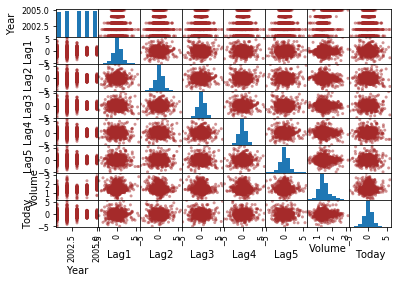

In [6]:
# Matrix of pairwise scatter plots
axes = pd.plotting.scatter_matrix(data, color="brown")

As one would expect, the correlations between the lag variables and today’s returns are close to zero. In other words, there appears to be little
correlation between today’s returns and previous days’ returns. The only
substantial correlation is between **Year** and **Volume**. By plotting the data we
see that Volume is increasing over time. In other words, the average number
of shares traded daily increased from 2001 to 2005.

## Logistic Regression

Next, we will fit a logistic regression model in order to predict **Direction**
using **Lag1** through **Lag5** and **Volume**.

In [7]:
# First we encode the qualitative variable direction into a binary 1 for Up 0 for Down
encode = lambda x: 1 if x == 'Up' else 0
data['Direction'] = data['Direction'].map(encode)
data.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,1
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,1
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,0
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,1
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,1


In [8]:
# To perform logistic regression we use the glm method (generalized linear model)

# If the encoding is not performed, the glm algorithm encodes the first occerance as 1 and all else as 0
# Generally it is good to encode it yourself, so that you know what the output means
fit1 = smf.glm('Direction~Lag1+Lag2+Lag3+Lag4+Lag5+Volume', data = data, family=sm.families.Binomial()).fit()
print(fit1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1250
Model:                            GLM   Df Residuals:                     1243
Model Family:                Binomial   Df Model:                            6
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -863.79
Date:                Mon, 25 May 2020   Deviance:                       1727.6
Time:                        10:44:29   Pearson chi2:                 1.25e+03
No. Iterations:                     4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1260      0.241     -0.523      0.6

The smallest p-value here is associated with **Lag1**. The negative coefficient
for this predictor suggests that if the market had a positive return yesterday,
then it is less likely to go up today. However, at a value of 0.15, the p-value
is still relatively large, and so there is no clear evidence of a real association
between **Lag1** and **Direction**.

### Making Predictions

In [9]:
# The predict() function will return P(Y=1|X)
# Without any arguments, it will return the probabilities for each row of the training data
print('Predicted probability of going Up:',fit1.predict()) #Predict

Predicted probability of going Up: [0.50708413 0.48146788 0.48113883 ... 0.5392683  0.52611829 0.51791656]


### Confusion Matrix

In [10]:
# Create DataFrame of predictions 
encode = lambda x: 1 if x > 0.5 else 0
predictions = pd.DataFrame({'Direction': [encode(x) for x in fit1.predict()]})
predictions.head()

,Direction
0,1
1,0
2,0
3,1
4,1


By definition a confusion matrix $C$ is such that $C_{i,j}$ is equal to the number of observations known to be in group $i$  but predicted to be in group $j$.

Thus in binary classification, the count of true negatives is $C_{0,0}$, false negatives is $C_{1,0}$, true positives is $C_{1,1}$ and false positives is $C_{0,1}$.

In [11]:
confusion_matrix(data['Direction'], predictions['Direction'])

array([[145, 457],
       [141, 507]], dtype=int64)

In [12]:
from sklearn.metrics import accuracy_score
print('The accuracy score is', 100 * accuracy_score(data['Direction'], predictions['Direction']), '%')

The accuracy score is 52.16 %


The diagonal elements of the confusion matrix indicate correct predictions,
while the off-diagonals represent incorrect predictions. Hence our model
correctly predicted that the market would go up on 507 days and that
it would go down on 145 days, for a total of 507 + 145 = 652 correct
predictions. In this case, logistic regression
correctly predicted the movement of the market 52.2 % of the time.
At first glance, it appears that the logistic regression model is working
a little better than random guessing. However, this result is misleading
because we trained and tested the model on the same set of 1, 250 observations. As we
have seen previously, the training error rate is often overly optimistic—it
tends to underestimate the test error rate. In order to better assess the accuracy of the logistic regression model in this setting, we can fit the model
using part of the data, and then examine how well it predicts the held out
data.

### Making Training and Test Data


In [13]:
#Split dataset into training and test sets
data_train = data[data["Year"] < 2005]
data_test = data[data["Year"] >= 2005]

# train Logistic Regression model with training data
fit2 = smf.glm('Direction~Lag1+Lag2+Lag3+Lag4+Lag5+Volume', data=data_train, family=sm.families.Binomial()).fit()
print(fit2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                  998
Model:                            GLM   Df Residuals:                      991
Model Family:                Binomial   Df Model:                            6
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -690.55
Date:                Mon, 25 May 2020   Deviance:                       1381.1
Time:                        10:44:29   Pearson chi2:                     998.
No. Iterations:                     4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1912      0.334      0.573      0.5

In [14]:
# test model with test data
Xtest = data_test[data.columns[1:-2]]
ytest = data_test[data.columns[-1]]
yprobs = fit2.predict(Xtest)

In [15]:
# calculate confusion matrix and accuracy
ypred =  [0 if y < 0.5 else 1 for y in yprobs]
confusion_matrix(ytest, ypred)

array([[77, 34],
       [97, 44]], dtype=int64)

In [16]:
print('The accuracy score is', 100 * accuracy_score(ytest, ypred), '%')

The accuracy score is 48.01587301587302 %


 The results are rather disappointing: the test error
rate is 52 %, which is worse than random guessing! Of course this result
is not all that surprising, given that one would not generally expect to be
able to use previous days’ returns to predict future market performance.


Let's try to improve our error rate by removing the least correlated variables (highest p-values)
We fit a model: Direction~Lag1+Lag2

In [17]:
# train Logistic Regression model with training data
fit3 = smf.glm('Direction~Lag1+Lag2', data=data_train, family=sm.families.Binomial()).fit()
yprobs = fit3.predict(Xtest)
ypred =  [0 if y < 0.5 else 1 for y in yprobs]
print('The accuracy score is', 100 * accuracy_score(ytest, ypred), '%')

The accuracy score is 55.952380952380956 %


In [18]:
confusion_matrix(ytest, ypred)

array([[ 35,  76],
       [ 35, 106]], dtype=int64)

Now the results appear to be a little better: 56% of the daily movements
have been correctly predicted. It is worth noting that in this case, a much
simpler strategy of predicting that the market will increase every day will
also be correct 56% of the time! Hence, in terms of overall error rate, the
logistic regression method is no better than the na¨ıve approach. However,
the confusion matrix shows that on days when logistic regression predicts
an increase in the market, it has a 58% accuracy rate. This suggests a
possible trading strategy of buying on days when the model predicts an increasing market, and avoiding trades on days when a decrease is predicted.
Of course one would need to investigate more carefully whether this small
improvement was real or just due to random chance.

## Linear Discriminant Analysis

In [19]:
fit4 = LDA()
# Only include the features lag1 and lag2 
Xtrain = data_train[data.columns[1:3]]
Xtest = data_test[data.columns[1:3]]
ytrain = data_train[data.columns[-1]]
fit4.fit(Xtrain, ytrain)
ypred = fit4.predict(Xtest)
confusion_matrix(ytest, ypred)

array([[ 35,  76],
       [ 35, 106]], dtype=int64)

In [20]:
accuracy_score(ytest, ypred)

0.5595238095238095

The LDA logistic regression predictions are almost identical in this case.

## Quadratic Discriminant Analysis

Like LDA, QDA is a classifier generated by fitting class conditional densities to the data and using Bayes’ rule. Instead of a linear decision boundary, it uses a quadratic boundary.

In [21]:
fit5 = QDA()
fit5.fit(Xtrain, ytrain)
ypred = fit5.predict(Xtest)

confusion_matrix(ytest, ypred)

array([[ 30,  81],
       [ 20, 121]], dtype=int64)

In [22]:
accuracy_score(ytest, ypred)

0.5992063492063492

Interestingly, the QDA predictions are accurate almost 60% of the time,
even though the 2005 data was not used to fit the model. This level of accuracy is quite impressive for stock market data, which is known to be quite
hard to model accurately. This suggests that the quadratic form assumed
by QDA may capture the true relationship more accurately than the linear
forms assumed by LDA and logistic regression.

## K-Nearest Neighbors

Another classification technique we will try is K-Nearest Neighbors, which groups data based on similarity measures (i.e., distance).

In [23]:
# First, let's try with n_neighbors=1
fit6 = KNeighborsClassifier(n_neighbors=1)
fit6.fit(Xtrain, ytrain)
ypred = fit6.predict(Xtest)
confusion_matrix(ytest, ypred)

array([[43, 68],
       [58, 83]], dtype=int64)

In [24]:
accuracy_score(ytest, ypred)

0.5

The results using K = 1 are not very good, since only 50 % of the observations are correctly predicted. Of course, it may be that K = 1 results in an
overly flexible fit to the data. We repeat the analysis using K = 3.

In [25]:
fit7 = KNeighborsClassifier(n_neighbors=3)
fit7.fit(Xtrain, ytrain)
ypred = fit7.predict(Xtest)
confusion_matrix(ytest, ypred)

array([[48, 63],
       [55, 86]], dtype=int64)

In [26]:
accuracy_score(ytest, ypred)

0.5317460317460317

Increasing K further turns out to provide no further improvements. In fact, we may be running into the risk of overfitting, since stock market data is noisy. It appears that for this data, QDA provides the best results of the methods that we have examined so far.

# Default Data

In the following section, we will explore classification using the **default** dataset as well. We will go further in-depth into logistic regression, and provide a detailed look into additional classification measurements.

In [27]:
data_original = pd.read_csv('Default.csv')
data_original.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [28]:
#Encode the categorical variables
data = data_original.copy()
encode = lambda x: 1 if x == 'Yes' else 0
data['student'] = data['student'].map(encode)

#We can also encode using one line
data['default_encoded'] = [1 if data['default'][x]=='Yes' else 0 for x in range(len(data))]
data.head()

,default,student,balance,income,default_encoded
0,No,0,729.526495,44361.625074,0
1,No,1,817.180407,12106.134700,0
2,No,0,1073.549164,31767.138947,0
3,No,0,529.250605,35704.493935,0
4,No,0,785.655883,38463.495879,0


The goal here is to predict if a given person defaults given data on *if they are a student, balance and income*. Linear regression can predict values outside of the range [0, 1]. Logistic regression achieves this by predicting the probability that a person defaults given the data.


$$\text{Pr}(\text{default} = \text{Yes}|\text{features})$$

### Trying out Linear Regression

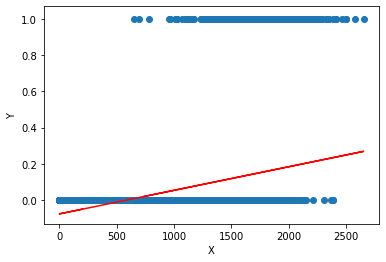

In [29]:
# linear regression in sklearn
data_np = data.values
X = data_np[:,2].reshape(len(data), 1)
y = data_np[:,4].reshape(len(data), 1)
regr = LinearRegression().fit(X, y)
plt.scatter(X, y);
plt.plot(X, regr.predict(X), color='red');
plt.xlabel('X');
plt.ylabel('Y');

Looking at the graph above, we see that there is no way to divide and seperate the two groups of defaulters without misclassifying some people. A lot of datapoints overlap with each other. Linear regression is a bad model for this categorical data. Now lets fit the logistic regression model and obtain the coefficient estimates.

## Simple Logistic Regression

### Constructing a Model
Like we did with linear regression, lets first consider predicting default with only one feature, *balance*. The goal is to predict the following probabilities,

$$\text{Pr}(\text{default} = \text{Yes}|\text{balance})$$

Since we are predicting probabilities, we need to choose a function to limit the range of the output to $[0,1]$. There are many such functions, we will be working with the logistic function today.

$$\text{Pr}(\text{default} = \text{Yes}|\text{balance}) = \frac{e^{\beta_0+\beta_1X_{\text{balance}}}}{1+e^{\beta_0+\beta_1X_{\text{balance}}}}$$


$$\text{Pr}(\text{default} = \text{No}|\text{balance}) = 1-\frac{e^{\beta_0+\beta_1X_{\text{balance}}}}{1+e^{\beta_0+\beta_1X_{\text{balance}}}} = \frac{1}{1+e^{\beta_0+\beta_1X_{\text{balance}}}}$$

We can also write the log odds ratio

$$\log{\left(\frac{\text{Pr}(\text{default} = \text{Yes}|\text{balance})}{1-\text{Pr}(\text{default} = \text{Yes}|\text{balance})}\right)} = \log{\left(\frac{\text{Pr}(\text{default} = \text{Yes}|\text{balance})}{\text{Pr}(\text{default} = \text{No}|\text{balance})}\right)} = \beta_0+\beta_1X_{\text{balance}}$$


Like linear regression, the goal now is to estimate the values of $\beta_0$ and $\beta_1$. This is achieved by using *maximum likelihood* estimator. Unlike linear regression there is no closed form solution.

In [30]:
#To perform logistic regression we use the glm method (generalized linear model)

#If the encoding is not performed, the glm algorithm encodes the first occerance as 1 and all else as 0
# Generally it is good to encode it yourself, so that you know what the output means
fit1 = smf.glm('default_encoded~balance', data = data, family=sm.families.Binomial()).fit()
print(fit1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        default_encoded   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9998
Model Family:                Binomial   Df Model:                            1
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -798.23
Date:                Mon, 25 May 2020   Deviance:                       1596.5
Time:                        10:44:30   Pearson chi2:                 7.15e+03
No. Iterations:                     9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.6513      0.361    -29.491      0.0

The summary table above shows that the coefficients are, $\beta_0 = -10.6513,\beta_1 = 0.0055$

We cannot interpret these results as easily as linear regression because the relationship between the probabilities and coefficients is non linear. However we can interpret the sign. Because $\beta_1$ is positive, this suggests that an increase in ballance leads to an increase in the probability that a given person is a defaulter. 

We can model the relationship between balance and the probability of being a defaulter below.

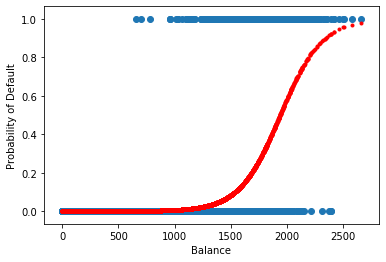

In [31]:
#fit1.fittedvalues
plt.plot(data['balance'], fit1.predict(data['balance']), '.', color='red')
plt.scatter(data['balance'], data['default_encoded'])
plt.xlabel('Balance');
plt.ylabel('Probability of Default');

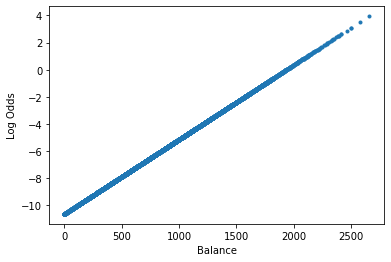

In [32]:
plt.plot(data['balance'],np.log(fit1.fittedvalues/(1-fit1.fittedvalues)),'.');
plt.xlabel('Balance');
plt.ylabel('Log Odds');

### Making Predictions

Restating the logistic regression model,

$$\text{Pr}(\text{default} = \text{Yes}|\text{balance}) = \frac{e^{-10.6513+0.0055X_{\text{balance}}}}{1+e^{-10.6513+0.0055X_{\text{balance}}}}$$

Given a balance we can now predict the probability that a given person is a defaulter. For example, if a person has a bank ballance of $\$2000$, their probability of defaulting, given this data is,

$$\text{Pr}(\text{default} = \text{Yes}|\text{balance}) = \frac{e^{-10.6513+0.0055(2000)}}{1+e^{-10.6513+0.0055(2000)}} = 0.586302$$

finding this prediction using code,

In [33]:
new_data = pd.DataFrame({'balance':[2000]}) #Initialize new dataframe with new data
print('Predicted probability of default:',fit1.predict(new_data)[0]) #Predict

Predicted probability of default: 0.5857693698313314


### Confidence Intervals

Like linear regression, we are estimating the coefficient values in logistic regression. Therefore, we get a confidence interval for our estimates. The 95% confidence intervals are shown above in the summary statistics.

$$\beta_1 = [0.005,0.006]$$

Since we have the coefficients, we can also perform hypothesis tests to test the significance of each variable. Like linear regression, if we have only continuous variables the p-values are easily obtained to check significance.

In [34]:
#P-Values
fit1.pvalues

Intercept    3.723661e-191
balance      2.010854e-137
dtype: float64

Looking at the p-values above, we can reject the null hypothesis that $\beta_1 = 0$ at a 0.05 level.

An alternative test we performed in linear regression is ANOVA (analysis of variance). Unfortunately, we were unable to find any packages to perform this test for logistic regression in Python. However, we can manually perform an ANOVA type 1 test using the $\chi^2$ test.

In [35]:
deviance = fit1.null_deviance-fit1.deviance
p_value = 1-sci.chi2.cdf(deviance,1) #1 degree of freedom
print("P Value = ", p_value)

P Value =  0.0


As shown above, we see that after performing the $\chi^2$ test, we can reject the null hypothesis that $\beta_1 = 0$ because the p-value is a very small number (so small that Python approximates to 0).

### Constructing a Classifier

Now that we have constructed a model and showcased how predictions are made, these predictions are still in terms of probabilities. We now need to decide on how to convert these probabilities back into categories (Yes/No) of default. This process is called classification and the rules we choose depends on the overall purpose of our project. We could do any one of the following,

1. Majority vote, if >0.5 "Yes", else "No"
2. Conservative position from the bank's perspective
    + example: if >0.2 "Yes", else "No"
3. Lenient position from the bank's perspective
    + example: if >0.8 "Yes", else "No"
    
For illustrative purposes, lets implement the **majority** vote. This states that,

$$\text{Predicted Default} = \begin{cases}\text{Yes},& \text{if } \text{Pr}(\text{default} = \text{Yes}|\text{balance})>0.5 \\ \text{No},&\text{Otherwise}\end{cases}$$

If we wish to overlay this classifier onto the two dimensional plane and obtain a classification boundary we substitute the above equation and solve.

A "Yes" vote is constituted by,

$$ \frac{e^{-10.6513+0.0055X_{\text{Balance}}}}{1+e^{-10.6513+0.0055X_{\text{Balance}}}}>0.5$$

Manipulating the equation, we get,

$$\log{\left(\frac{0.5}{1-0.5}\right)} = 0 < -10.6513+0.0055X_{\text{Balance}}$$

Hence, we clasify a "Yes" vote if,

$$X_\text{Balance}>1936.6$$


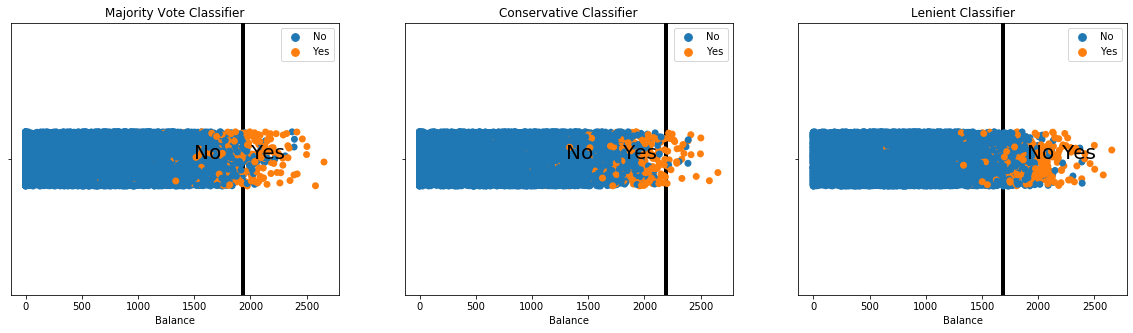

In [36]:
#Majority 
majority = (np.log(0.5/(1-0.5))-fit1.params[0])/fit1.params[1]

#lenient
lenient = (np.log(0.2/(1-0.2))-fit1.params[0])/fit1.params[1]

#Conservative
conserv = (np.log(0.8/(1-0.8))-fit1.params[0])/fit1.params[1]


####Code for plotting#######

plt.figure(figsize=(20, 5))
axis = plt.axis(ymin=-0.15,ymax=0.15)

plt.subplot(1,3,1)
sns.stripplot(x = data['balance'],y = [""]*len(data),hue = data['default'],jitter = True,size = 7) 
plt.axvline(x = majority,c='Black',linewidth=4)
plt.text(2000,0,'Yes',fontsize=20)
plt.text(1500,0,'No',fontsize=20)
plt.xlabel('Balance')
plt.title('Majority Vote Classifier')
plt.legend(loc = 'upper right')

plt.subplot(1,3,2)
sns.stripplot(x = data['balance'],y = [""]*len(data),hue = data['default'],jitter = True,size = 7) 
plt.axvline(x = conserv,c='Black',linewidth=4)
plt.text(1800,0,'Yes',fontsize=20)
plt.text(1300,0,'No',fontsize=20)
plt.xlabel('Balance')
plt.title('Conservative Classifier')
plt.legend(loc = 'upper right')

plt.subplot(1,3,3)
sns.stripplot(x = data['balance'],y = [""]*len(data),hue = data['default'],jitter = True,size = 7) 
plt.axvline(x = lenient,c='Black',linewidth=4)
plt.text(2200,0,'Yes',fontsize=20)
plt.text(1900,0,'No',fontsize=20)
plt.xlabel('Balance')
plt.title('Lenient Classifier')
plt.legend(loc = 'upper right')

plt.show()

The graph above shows that everything to the right of the thick line is classified as "Yes" for defaulting. We see here that every decision results in certain people being misclassified. Hence, constructing a classifier is more of a judgment call depending on the nature of the project. This decision however, must by followed by strong statistical reasoning. The next section discusses evaluating the quality of a classifier.

There are a few important metrics we may choose to quantify the quality of our classifier. These metrics include,

1. ROC Curve
    + Sensitivity
    + Specificity
    + AUC (Area Under Curve)
2. Misclassification Error

Definitions for sensitivity, specificity, positive prediction, negative prediction and misclassification error are given in Tables 4.6 and 4.7 in the ISL textbook.

The goal now is to construct these tables for our classifier.

In [37]:
#Table for Majority Vote Classifier
data['majority_default'] = ["Yes" if fit1.fittedvalues[x]>0.5 else "No" for x in range(len(data))]

In [38]:
#Confusion Matrix
#data.groupby(['default','majority_default']).size()
confusion_matrix(data['default'],data['majority_default'])

array([[9625,   42],
       [ 233,  100]], dtype=int64)

The table above is equivalent to the following table as seen in the textbook,

| True/Predicted | No |  Yes  |
|:--------------:|:---:|:----:|
|       No      | 9625 |  42 |
|       Yes       |  233 | 100 |

The following statistics can be derived from the table above,

$$\text{Sensitivity} = \frac{100}{100+233} = 0.3$$

$$1-\text{Specificity} = \frac{42}{42+9625} = 0.0043$$

$$\text{Positive Prediction Rate} = \frac{100}{100+42} = 0.704$$

$$\text{Negative Prediction Rate} = \frac{9625}{9625+233} = 0.976$$

$$\text{Misclassification Error} = \frac{233+42}{9625+42+233+100} = 0.0275$$

Now that we have obtained the statistics, how do we judge if it is good enough? 

We now calculate these statistics as we sweep through every possible classifier to obtain the **ROC and Misclassification error Curves**


In [39]:
def get_classification_curves(fit1,data,start,stop,num_points):
    # Misclassification error,sensitivity, specificity, positive prediction, negative prediction
    classifier = np.linspace(start = start,stop = stop,num = num_points,endpoint = True)

    #Initialize arrays
    true_pos = np.array([])
    false_pos = np.array([])
    pos_pred = np.array([])
    neg_pred = np.array([])
    misclassification = np.array([])

    #Loop
    for value in classifier:
        #Simple one line solution but extremely slow! We see that list comprehension is not always the best solution.
        #data['classifier'] = ["Yes" if fit1.fittedvalues[x]>value else "No" for x in range(len(data))]

        #Faster 4 line alternative using numpy
        temp = np.empty(len(data),dtype = '<U3')
        temp[:] = 'No'
        temp[np.where(fit1.fittedvalues>value)] = "Yes"
        data['classifier'] = temp

        table = confusion_matrix(data['default'],data['classifier'])
        tp = table[1,1] #True positive
        tn = table[0,0] #True Negative
        fn = table[1,0] #False Negative
        fp = table[0,1] # False positive
        
        #print(tp,tn,fp,fn)
        true_pos = np.append(true_pos,tp/(tp+fn)) # Sensitivity
        false_pos = np.append(false_pos,fp/(fp+tn)) # 1 - Specificity
        pos_pred = np.append(pos_pred,tp/(tp+fp))
        neg_pred = np.append(neg_pred,tn/(tn+fn))
        misclassification = np.append(misclassification,(fp+fn)/(fp+fn+tp+tn))
    return classifier,true_pos,false_pos,pos_pred,neg_pred,misclassification

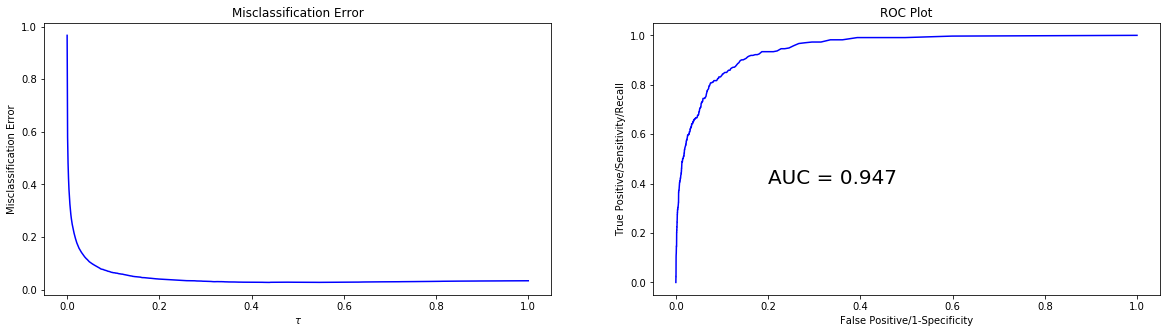

In [40]:
classifier,true_pos,false_pos,pos_pred,neg_pred,misclassification = get_classification_curves(fit1,data,1,0,1000)

#Plot Results
plt.figure(figsize=(20, 5))

# Misclassification Error
plt.subplot(1,2,1)
plt.plot(classifier,misclassification,c = 'blue')
plt.xlabel(r'$\tau$')
plt.ylabel('Misclassification Error')
plt.title('Misclassification Error')

#ROC
#Calculating AUC
#We wish to find the area between the curve and the xaxis till 1-specificity = 1.
#Because we cant sweep the classifier from 1-0 we see that the graph gets cut off
auc = np.trapz(true_pos,false_pos) # Numerical Integration using trapizoidal rule

plt.subplot(1,2,2)
plt.plot(false_pos,true_pos,c = 'blue')
plt.xlabel('False Positive/1-Specificity')
plt.ylabel('True Positive/Sensitivity/Recall')
plt.text(0.2,0.4,'AUC = %.3f'%auc,fontsize = 20)
plt.title('ROC Plot')
plt.show()

## Multiple Logistic Regression

The procedure followed in multiple logistic regression is the same as simple regression, the only difference being we cannot visualize the decision boundary being fit.

In [41]:
#Fit all Variables
fit2 = smf.glm('default_encoded~balance+student+income',data = data,family=sm.families.Binomial()).fit()
print(fit2.summary())
#The coefficients are correct, there is a typo in the book for the coefficient of income

                 Generalized Linear Model Regression Results                  
Dep. Variable:        default_encoded   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9996
Model Family:                Binomial   Df Model:                            3
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -785.77
Date:                Mon, 25 May 2020   Deviance:                       1571.5
Time:                        10:46:15   Pearson chi2:                 7.00e+03
No. Iterations:                     9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.8690      0.492    -22.079      0.0

Looking at the coefficients above, we can infer that an increase in balance still leads to an increase in the probability of default. Being a student however, leads to a decrease in the probability of defaulting because of the negative sign. Again, we cannot really comment on the magnitude of these numbers because the relationship is nonlinear. The model we have obtained is the following,

$$\text{Pr}(\text{default} = \text{Yes}|\text{balance}) = \frac{e^{-10.8690+0.0057X_{\text{balance}}+3.03\times10^{-6}X_{\text{income}}-0.6468X_{\text{Student[yes]}}}}{1+e^{-10.8690+0.0057X_{\text{balance}}+3.03\times10^{-6}X_{\text{income}}-0.6468X_{\text{Student[yes]}}}}$$

In [42]:
# fitting logistic regression with sklearn
X = data_np[:,1:]
y = data_np[:,0]
logregr = LogisticRegression().fit(X, y)
pred = logregr.predict(X)
pred_prob = logregr.predict_proba(X)
print(classification_report(y, pred))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00      9667
         Yes       1.00      1.00      1.00       333

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

